# 인공지능수학 — Overview
# AI는 무엇을 하는가, 그리고 이 수업은 무엇을 배우는가

---

> **이 노트북의 목적**  
> 본격적인 수업 전에 전체 그림을 먼저 보는 시간입니다.  
> 코드를 완전히 이해하지 않아도 됩니다. 결과를 보고 느끼는 것이 목표입니다.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_classification
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

---
# Part 1. 🪄 AI는 지금 무엇을 하고 있나

ChatGPT, Claude 같은 **생성형 AI**가 화제지만,  
AI가 가장 오랫동안, 가장 넓게 쓰여온 분야는 따로 있습니다.

## 두 가지 핵심 작업

| 작업 | 질문 형태 | 출력 | 예시 |
|---|---|---|---|
| **회귀 (Regression)** | 얼마나? | 숫자 | 집값, 주가, 기온 예측 |
| **분류 (Classification)** | 어느 쪽? | 범주 | 스팸 필터, 암 진단, 얼굴 인식 |

이 두 작업은 산업 현장에서 매일 수십억 번 실행되고 있습니다.  
넷플릭스 추천, 신용카드 사기 탐지, 의료 영상 판독 — 모두 회귀 또는 분류입니다.

---

## 실제 AI는 얼마나 복잡한 문제를 다루나?

아래 코드를 실행해보세요. 달 모양으로 섞인 두 그룹을 분류하는 문제입니다.  
직선 하나로는 도저히 나눌 수 없는 형태입니다.

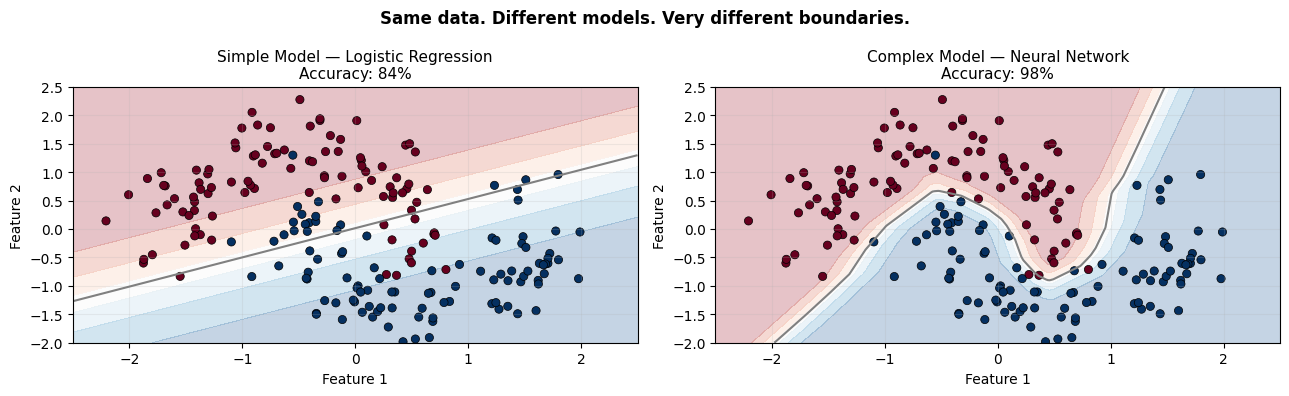

Simple model accuracy : 84%
Neural network accuracy: 98%


In [2]:
# Generate a dataset that cannot be separated by a straight line
X_moon, y_moon = make_moons(n_samples=200, noise=0.2, random_state=42)
sc = StandardScaler()
X_moon_s = sc.fit_transform(X_moon)

# Train two models: simple vs complex
lr_model  = LogisticRegression().fit(X_moon_s, y_moon)
mlp_model = MLPClassifier(hidden_layer_sizes=(20, 20),
                           max_iter=3000, random_state=42).fit(X_moon_s, y_moon)

# Draw decision boundaries
xx, yy = np.meshgrid(np.linspace(-2.5, 2.5, 300),
                      np.linspace(-2.0, 2.5, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

Z_lr  = lr_model.predict_proba(grid)[:,1].reshape(xx.shape)
Z_mlp = mlp_model.predict_proba(grid)[:,1].reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, Z, title, acc in [
    (axes[0], Z_lr,  'Simple Model — Logistic Regression', lr_model.score(X_moon_s, y_moon)),
    (axes[1], Z_mlp, 'Complex Model — Neural Network',     mlp_model.score(X_moon_s, y_moon))
]:
    ax.contourf(xx, yy, Z, alpha=0.25, cmap='RdBu')
    ax.contour(xx, yy, Z, levels=[0.5], colors='gray', linewidths=1.5)
    ax.scatter(X_moon_s[:,0], X_moon_s[:,1], c=y_moon,
               cmap='RdBu', edgecolors='k', s=35, linewidths=0.5)
    ax.set_title(f'{title}\nAccuracy: {acc*100:.0f}%', fontsize=11)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.grid(True, alpha=0.2)

plt.suptitle('Same data. Different models. Very different boundaries.',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Simple model accuracy : {lr_model.score(X_moon_s,  y_moon)*100:.0f}%")
print(f"Neural network accuracy: {mlp_model.score(X_moon_s, y_moon)*100:.0f}%")

> ❓ 신경망은 어떻게 저런 곡선 경계를 그릴 수 있을까요?  
> 그리고 단순 모델은 왜 직선밖에 못 그릴까요?
>
> 이 질문의 답이 이 수업 전체를 관통합니다.

---
# Part 2. 회귀(Regression)란 무엇인가

## 2-1. 정의

**회귀** = 입력 $\mathbf{x}$를 받아서 **연속적인 숫자** $\hat{y}$를 출력하는 것

$$f(\mathbf{x}) = \hat{y} \in \mathbb{R}$$

## 2-2. 실생활 예시

| 입력 $\mathbf{x}$ | 출력 $\hat{y}$ | 실제 사용처 |
|---|---|---|
| 아파트 면적, 층수, 위치 | 가격(만원) | 부동산 시세 예측 |
| 환자 나이, 혈압, 혈당 | 입원 기간(일) | 병원 자원 배분 |
| 과거 30일 주가 | 내일 주가 | 퀀트 투자 |
| 기온, 습도, 풍속 | 전력 수요(MW) | 발전소 운영 |

## 2-3. 가장 단순한 회귀: 직선 하나

가장 단순한 회귀 모델은 입력과 출력의 관계를 **직선**으로 표현합니다.

$$\hat{y} = wx + b$$

- $w$: 기울기(가중치) — 입력이 1 증가할 때 출력이 얼마나 변하는가
- $b$: 절편(편향) — 입력이 0일 때의 출력값

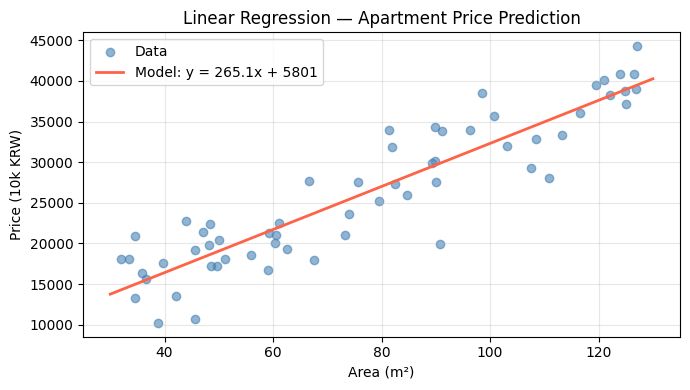

Learned: w = 265.1,  b = 5801
Interpretation: area +1m² → price +265 (10k KRW)
Prediction for 84m²: 28,071 (10k KRW)


In [3]:
# Simple regression: apartment area → price
np.random.seed(42)
n = 60
area  = np.random.uniform(30, 130, n)
price = 280 * area + 5000 + np.random.randn(n) * 4000  # true: price ≈ 280*area + 5000

# Fit a linear model
model = LinearRegression()
model.fit(area.reshape(-1,1), price)
w, b = model.coef_[0], model.intercept_

x_line = np.linspace(30, 130, 100)
y_line = w * x_line + b

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(area, price, alpha=0.6, color='steelblue', label='Data')
ax.plot(x_line, y_line, color='tomato', linewidth=2,
        label=f'Model: y = {w:.1f}x + {b:.0f}')
ax.set_xlabel('Area (m²)')
ax.set_ylabel('Price (10k KRW)')
ax.set_title('Linear Regression — Apartment Price Prediction')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Learned: w = {w:.1f},  b = {b:.0f}")
print(f"Interpretation: area +1m² → price +{w:.0f} (10k KRW)")
print(f"Prediction for 84m²: {w*84+b:,.0f} (10k KRW)")

---
# Part 3. 분류(Classification)란 무엇인가

## 3-1. 정의

**분류** = 입력 $\mathbf{x}$를 받아서 **범주(클래스)** 를 출력하는 것

$$f(\mathbf{x}) = \hat{y} \in \{0, 1\} \quad \text{또는} \quad \{0, 1, 2, \ldots, K\}$$

## 3-2. 실생활 예시

| 입력 $\mathbf{x}$ | 출력 $\hat{y}$ | 실제 사용처 |
|---|---|---|
| 이메일 내용 | 스팸(1) / 정상(0) | 스팸 필터 |
| X-ray 이미지 | 양성(1) / 음성(0) | 암 진단 보조 |
| 거래 금액, 위치, 시간 | 사기(1) / 정상(0) | 신용카드 사기 탐지 |
| 꽃잎 길이·너비 | 세 종류 중 하나 | 품종 분류 |

## 3-3. 가장 단순한 분류: 직선으로 나누기

가장 단순한 이진분류는 두 그룹을 **직선(결정경계)** 으로 나눕니다.  
직선의 한쪽은 클래스 0, 다른 쪽은 클래스 1입니다.

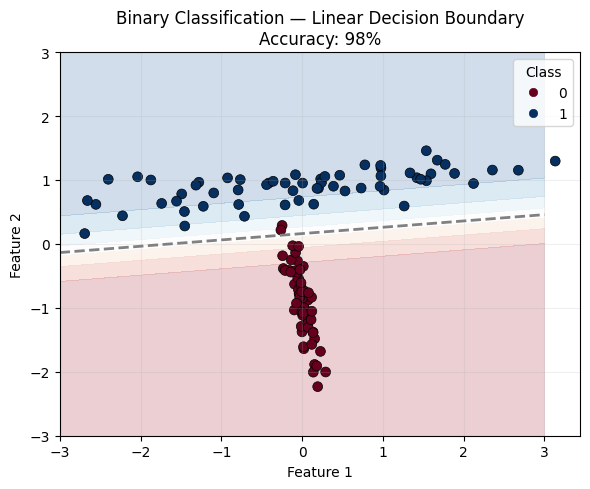

Decision boundary: a straight line separating the two groups
Accuracy: 98%


In [ ]:
# Simple binary classification: two linearly separable groups
X_cls, y_cls = make_classification(
    n_samples=120, n_features=2, n_redundant=0,
    n_informative=2, random_state=5, n_clusters_per_class=1,
    class_sep=1.5
)
X_cls = StandardScaler().fit_transform(X_cls)

clf = LogisticRegression().fit(X_cls, y_cls)

xx, yy = np.meshgrid(np.linspace(-3, 3, 200), np.linspace(-3, 3, 200))
Z = clf.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:,1].reshape(xx.shape)

fig, ax = plt.subplots(figsize=(6, 5))
ax.contourf(xx, yy, Z, alpha=0.2, cmap='RdBu')
ax.contour(xx, yy, Z, levels=[0.5], colors='gray',
           linewidths=2, linestyles='--')
scatter = ax.scatter(X_cls[:,0], X_cls[:,1], c=y_cls,
                     cmap='RdBu', edgecolors='k', s=50, linewidths=0.5)
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_title(f'Binary Classification — Linear Decision Boundary\nAccuracy: {clf.score(X_cls, y_cls)*100:.0f}%')
ax.legend(*scatter.legend_elements(), title='Class')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

print(f"Decision boundary: a straight line separating the two groups")
print(f"Accuracy: {clf.score(X_cls, y_cls)*100:.0f}%")

---
# Part 4. 이 수업의 포지션

## 4-1. 왜 단순한 문제를 다루는가

실제 AI가 다루는 문제는 복잡합니다. 입력이 수백만 차원이고, 모델은 수십억 개의 파라미터를 가집니다.  
이런 모델을 처음부터 수학적으로 분석하는 것은 불가능합니다.

**이 수업의 전략:**

$$\text{복잡한 문제} \xrightarrow{\text{핵심 수학은 같다}} \text{매우 단순한 문제로 수학 이해}$$

이 수업에서 다루는 예시들은 사실 AI 없이 풀 수 있는 문제들입니다.  
하지만 **수학적 원리는 복잡한 AI와 완전히 동일**합니다.

## 4-2. 이 수업에서 다루는 모델

이 수업에서 배우는 모든 모델은 결국 **인공뉴런(artificial neuron) 하나**입니다.

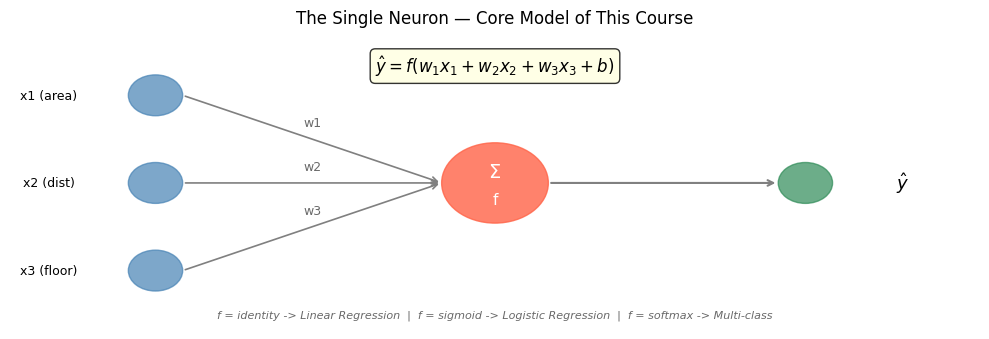

In [6]:
# Visualize the single neuron model
# Note: Korean text removed from ax.text() — DejaVu Sans does not support Korean glyphs
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.set_xlim(0, 10)
ax.set_ylim(0, 4)
ax.axis('off')

# Input nodes
inputs = [(1.5, 3.2), (1.5, 2.0), (1.5, 0.8)]
labels = ['x1 (area)', 'x2 (dist)', 'x3 (floor)']
for (x, y), label in zip(inputs, labels):
    ax.add_patch(plt.Circle((x, y), 0.28, color='steelblue', alpha=0.7))
    ax.text(x - 1.1, y, label, ha='center', va='center', fontsize=9)

# Neuron
neuron_x, neuron_y = 5.0, 2.0
ax.add_patch(plt.Circle((neuron_x, neuron_y), 0.55, color='tomato', alpha=0.8))
ax.text(neuron_x, neuron_y + 0.15, r'$\Sigma$',
        ha='center', va='center', fontsize=14, color='white')
ax.text(neuron_x, neuron_y - 0.22, 'f',
        ha='center', va='center', fontsize=11, color='white')

# Output node
out_x, out_y = 8.2, 2.0
ax.add_patch(plt.Circle((out_x, out_y), 0.28, color='seagreen', alpha=0.7))
ax.text(out_x + 1.0, out_y, r'$\hat{y}$', ha='center', va='center', fontsize=13)

# Arrows: inputs -> neuron
for (x, y), wlabel in zip(inputs, ['w1', 'w2', 'w3']):
    ax.annotate('', xy=(neuron_x - 0.55, neuron_y), xytext=(x + 0.28, y),
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.2))
    ax.text((x + 0.28 + neuron_x - 0.55) / 2, (y + neuron_y) / 2 + 0.18,
            wlabel, ha='center', fontsize=9, color='dimgray')

# Arrow: neuron -> output
ax.annotate('', xy=(out_x - 0.28, out_y), xytext=(neuron_x + 0.55, neuron_y),
            arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))

# Formula box
ax.text(5.0, 3.6,
        r'$\hat{y} = f(w_1 x_1 + w_2 x_2 + w_3 x_3 + b)$',
        ha='center', va='center', fontsize=12,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

# Model label — plain text only
ax.text(5.0, 0.2,
        'f = identity -> Linear Regression  |  '
        'f = sigmoid -> Logistic Regression  |  '
        'f = softmax -> Multi-class',
        ha='center', va='center', fontsize=8, color='dimgray', style='italic')

ax.set_title('The Single Neuron — Core Model of This Course', fontsize=12, pad=10)
plt.tight_layout()
plt.show()


이 수업에서 배우는 세 모델은 모두 **뉴런 하나** 안에서 $f$만 바꾼 것입니다.

| 모델 | 활성화 함수 $f$ | 출력 | 용도 |
|---|---|---|---|
| 선형회귀 | $f(z) = z$ (항등함수) | 연속 숫자 | 가격, 온도 예측 |
| 로지스틱회귀 | $f(z) = \sigma(z) = \frac{1}{1+e^{-z}}$ | 0~1 확률 | 이진 분류 |
| 소프트맥스 | $f(z) = \text{softmax}(z)$ | 클래스별 확률 | 다중 클래스 분류 |

---
# Part 5. 이 수업을 마치면 — 딥러닝으로 가는 길

## 5-1. 뉴런 하나의 한계

뉴런 하나는 직선(또는 평면) 경계만 그릴 수 있습니다.  
Part 1에서 본 달 모양 데이터처럼 **비선형 패턴**은 처리할 수 없습니다.

## 5-2. 뉴런을 여러 개 쌓으면?

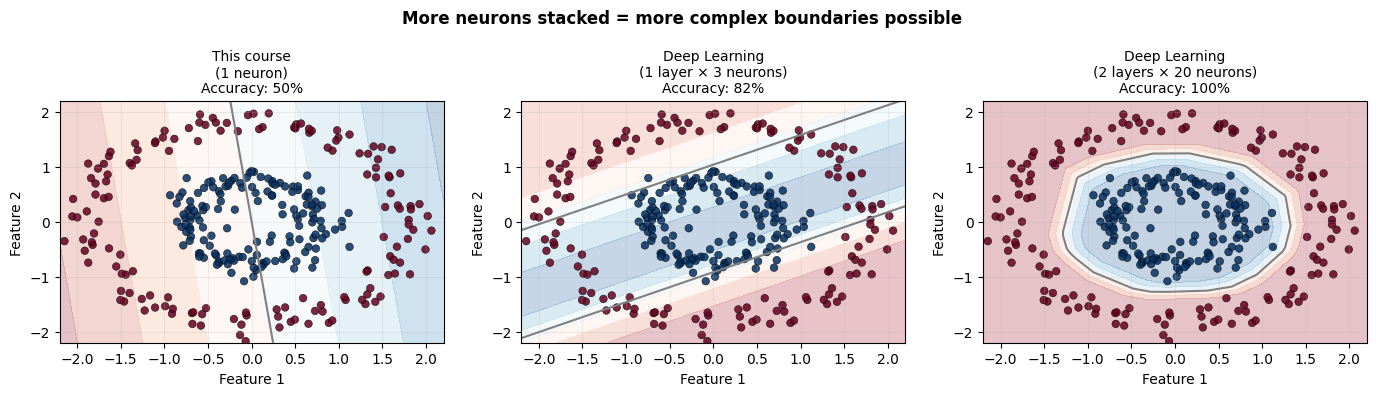

In [7]:
# What becomes possible when we stack multiple neurons?
# Using concentric circles — impossible to separate with a straight line
from sklearn.datasets import make_circles

X_circ, y_circ = make_circles(n_samples=300, noise=0.08, factor=0.4, random_state=42)
X_s = StandardScaler().fit_transform(X_circ)

xx, yy = np.meshgrid(np.linspace(-2.2, 2.2, 300),
                      np.linspace(-2.2, 2.2, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

configs = [
    ('This course\n(1 neuron)',              LogisticRegression()),
    ('Deep Learning\n(1 layer × 3 neurons)', MLPClassifier((3,),    max_iter=5000, random_state=42)),
    ('Deep Learning\n(2 layers × 20 neurons)', MLPClassifier((20,20), max_iter=5000, random_state=42)),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (title, model) in zip(axes, configs):
    model.fit(X_s, y_circ)
    Z   = model.predict_proba(grid)[:,1].reshape(xx.shape)
    acc = model.score(X_s, y_circ)

    ax.contourf(xx, yy, Z, alpha=0.25, cmap='RdBu')
    ax.contour(xx, yy, Z, levels=[0.5], colors='gray', linewidths=1.5)
    ax.scatter(X_s[:,0], X_s[:,1], c=y_circ,
               cmap='RdBu', edgecolors='k', s=30, linewidths=0.4, alpha=0.85)
    ax.set_title(f'{title}\nAccuracy: {acc*100:.0f}%', fontsize=10)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.grid(True, alpha=0.2)

plt.suptitle('More neurons stacked = more complex boundaries possible',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 5-3. 이 수업과 딥러닝 수업의 관계

```
인공지능수학 (이 수업)          딥러닝 입문 (다음 수업)
─────────────────────          ─────────────────────────────
뉴런 1개                  →    뉴런 수백~수천 개를 층층이 쌓음
선형 결정경계                   복잡한 비선형 경계
단순한 데이터 (굳이 AI 불필요)  실제 문제 (이미지, 텍스트, 음성)
수학 원리 이해에 집중            PyTorch로 구현에 집중
손으로 gradient 계산            autograd가 자동으로 계산
```

딥러닝 수업에서 `optimizer.step()` 한 줄이 어떻게 동작하는지 이해하는 사람과  
그냥 쓰는 사람의 차이 — 그게 이 수업의 목표입니다.

---
# Part 6. 이 수업에서 배우는 수학 — 미리보기

| 주차 | 주제 | 역할 |
|:---:|---|---|
| 1 | 벡터·행렬·NumPy | 데이터를 숫자로 표현하는 언어 |
| 2~4 | 선형회귀·미분·경사하강법 | "좋은 $w$를 어떻게 찾는가" |
| 5 | 확률·최대우도추정 | "왜 이 손실함수인가" |
| 6~7 | 로지스틱회귀·이진분류 | 뉴런에 sigmoid 붙이기 |
| 8 | Softmax·다중 클래스 | 출력이 여러 개일 때 |
| 9~11 | Forward/Backward Pass·Chain Rule | 뉴런을 쌓으면 어떻게 학습하는가 |
| 12~15 | 프로젝트 | 전체를 직접 구현·분석 |

---
# 💭 생각해볼 질문

1. 회귀와 분류의 출력이 다른 이유는 무엇인가요? (연속 vs 범주)
2. 뉴런 하나로 달 모양 데이터를 절대 분류할 수 없는 이유는 무엇일까요?
3. 딥러닝 수업에서 `optimizer.step()`이 하는 일은 이 수업의 어떤 개념과 연결될까요?

---
# 🤖 LLM 파트너 활용 — 오버뷰 버전

오늘 본 내용 중 궁금한 것을 LLM에게 물어보세요. 예시:

```
회귀와 분류의 차이를 실생활 예시 5가지씩 들어서 설명해줘.
각 예시마다 입력이 무엇이고 출력이 무엇인지도 알려줘.
```

```
뉴런 하나로는 XOR 문제를 풀 수 없다고 하는데,
XOR이 뭔지, 왜 뉴런 하나로 안 되는지 그림으로 설명해줘.
(다음 학기 딥러닝 수업의 복선입니다)
```

---
# ➡️ 수업 예고

**1주차: 벡터, 행렬, NumPy**

오늘 본 모든 모델에서 데이터는 **벡터**이고 연산은 **행렬 곱**입니다.  
다음 주는 이 계산의 언어를 배웁니다.